In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, f1_score, r2_score, mean_squared_error, mean_absolute_error

plt.rcParams.update({
    'figure.facecolor': '#F8FAFC',
    'axes.facecolor': '#F8FAFC',
    'axes.spines.top': False,
    'axes.spines.right': False
})

COLORS = {'best': '#2563EB', 'others': '#94A3B8', 'accent': '#F59E0B', 'text': '#1E293B'}

print('✅ All imports successful!')

✅ All imports successful!


In [2]:
# ── APNA CSV YAHAN DALO ──────────────────────
CSV_PATH = 'your_data.csv'   # ← apna file name
TARGET   = 'target'          # ← apna target column
TUNE     = True              # False = fast run
# ─────────────────────────────────────────────

try:
    df = pd.read_csv(CSV_PATH)
    print(f'✅ Loaded: {CSV_PATH}')
except FileNotFoundError:
    print('⚠️  CSV nahi mila — Titanic sample use ho raha hai')
    from sklearn.datasets import fetch_openml
    raw = fetch_openml('titanic', version=1, as_frame=True, parser='auto')
    df  = raw.frame[['pclass','sex','age','sibsp','parch','fare','embarked','survived']].dropna()
    df.columns = [c.lower() for c in df.columns]
    TARGET = 'survived'

# ID columns drop karo
drop_cols = [c for c in df.columns if c.lower() in {'id','index','unnamed: 0'}]
df.drop(columns=drop_cols, inplace=True, errors='ignore')

print(f'Shape  : {df.shape}')
print(f'Target : {TARGET}')
df.head(3)

⚠️  CSV nahi mila — Titanic sample use ho raha hai
Shape  : (1043, 8)
Target : survived


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,1,female,29.0000,0,0,211.3375,S,1
1,1,male,0.9167,1,2,151.5500,S,1
2,1,female,2.0000,1,2,151.5500,S,0


In [3]:
def detect_problem(y):
    unique, total = y.nunique(), len(y)
    if not pd.api.types.is_numeric_dtype(y) or unique < 20 or (unique/total) < 0.05:
        return 'classification', f'{unique} unique values → low cardinality'
    return 'regression', f'{unique} unique values → high cardinality'

y_raw = df[TARGET].copy()
X     = df.drop(columns=[TARGET])

PROBLEM, reason = detect_problem(y_raw)

# Target encode karo
le = None
if PROBLEM == 'classification':
    le = LabelEncoder()
    y  = pd.Series(le.fit_transform(y_raw.astype(str)), name=TARGET)
else:
    y  = y_raw.astype(float)

print(f'🎯 Problem Type : {PROBLEM.upper()}')
print(f'   Reason       : {reason}')
print(f'   Dataset size : {len(df)} rows')

🎯 Problem Type : CLASSIFICATION
   Reason       : 2 unique values → low cardinality
   Dataset size : 1043 rows


In [4]:
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
], remainder='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y if PROBLEM == 'classification' else None
)

print(f'✅ Numeric cols    : {num_cols}')
print(f'✅ Categorical cols: {cat_cols}')
print(f'✅ Train / Test    : {len(X_train)} / {len(X_test)}')

✅ Numeric cols    : ['pclass', 'age', 'sibsp', 'parch', 'fare']
✅ Categorical cols: ['sex', 'embarked']
✅ Train / Test    : 834 / 209


In [5]:
def get_candidates(problem, n):
    if problem == 'classification':
        cands = [
            ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42),
             {'clf__C': [0.01, 0.1, 1, 10]}),
            ('Random Forest', RandomForestClassifier(random_state=42),
             {'clf__n_estimators': [50,100], 'clf__max_depth': [None,5,10]}),
            ('Gradient Boosting', GradientBoostingClassifier(random_state=42),
             {'clf__n_estimators': [50,100], 'clf__learning_rate': [0.05,0.1,0.2]}),
        ]
        if n < 10_000:
            cands.append(('SVM', SVC(probability=True, random_state=42),
                          {'clf__C': [0.1,1,10], 'clf__kernel': ['rbf','linear']}))
    else:
        cands = [
            ('Linear Regression', LinearRegression(), {}),
            ('Ridge', Ridge(), {'clf__alpha': [0.1,1,10,100]}),
            ('Random Forest', RandomForestRegressor(random_state=42),
             {'clf__n_estimators': [50,100], 'clf__max_depth': [None,5,10]}),
            ('Gradient Boosting', GradientBoostingRegressor(random_state=42),
             {'clf__n_estimators': [50,100], 'clf__learning_rate': [0.05,0.1]}),
        ]
    return cands

candidates = get_candidates(PROBLEM, len(df))
scoring    = 'accuracy' if PROBLEM == 'classification' else 'r2'
results    = []

print('🏋️  Training models...\n')
for name, estimator, params in candidates:
    pipe = Pipeline([('pre', preprocessor), ('clf', estimator)])
    
    if TUNE and params:
        search = RandomizedSearchCV(pipe, params, n_iter=6, cv=3,
                                    scoring=scoring, random_state=42, n_jobs=-1)
        search.fit(X_train, y_train)
        pipe = search.best_estimator_
    else:
        pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    
    if PROBLEM == 'classification':
        score = accuracy_score(y_test, y_pred)
        extra = {'F1': f1_score(y_test, y_pred, average='weighted', zero_division=0)}
    else:
        score = r2_score(y_test, y_pred)
        extra = {'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                 'MAE' : mean_absolute_error(y_test, y_pred)}

    results.append({'name': name, 'pipe': pipe, 'score': score, 'extra': extra})
    print(f'  ✔ {name:<25} {scoring} = {score:.4f}')

results.sort(key=lambda r: r['score'], reverse=True)
best = results[0]
print(f'\n🏆 Best Model: {best["name"]}  ({scoring} = {best["score"]:.4f})')

🏋️  Training models...

  ✔ Logistic Regression       accuracy = 0.7703
  ✔ Random Forest             accuracy = 0.8230
  ✔ Gradient Boosting         accuracy = 0.8134
  ✔ SVM                       accuracy = 0.7943

🏆 Best Model: Random Forest  (accuracy = 0.8230)


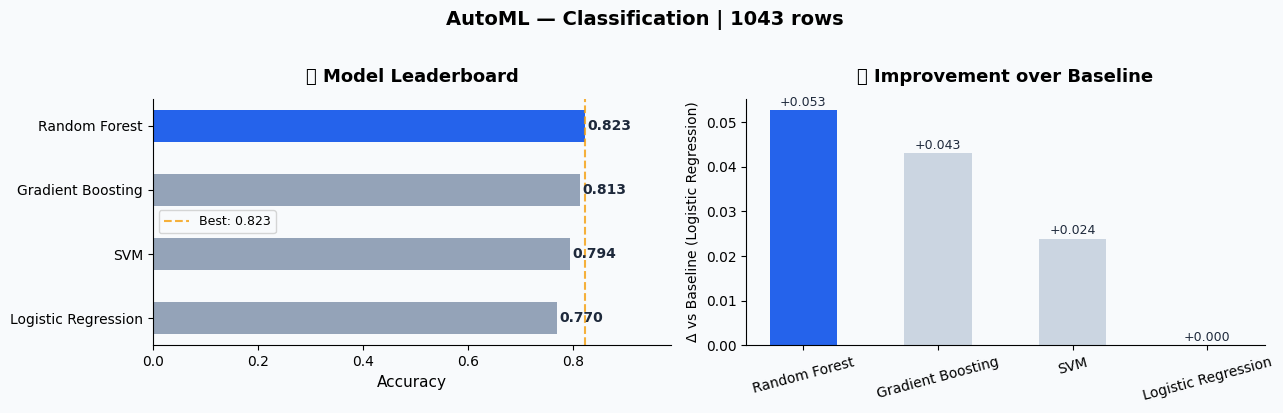

📸 Saved: model_comparison.png


In [6]:
names  = [r['name']  for r in results]
scores = [r['score'] for r in results]
colors = [COLORS['best'] if n == best['name'] else COLORS['others'] for n in names]
metric_label = 'Accuracy' if PROBLEM == 'classification' else 'R² Score'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Plot 1: Leaderboard ──
ax = axes[0]
bars = ax.barh(names[::-1], scores[::-1], color=colors[::-1], height=0.5, edgecolor='none')
for bar, sc in zip(bars, scores[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{sc:.3f}', va='center', fontsize=10, fontweight='bold', color=COLORS['text'])
ax.set_xlim(0, min(1.0, max(scores) * 1.2))
ax.set_xlabel(metric_label, fontsize=11)
ax.set_title('🏆 Model Leaderboard', fontsize=13, fontweight='bold', pad=12)
ax.axvline(best['score'], color=COLORS['accent'], lw=1.5, ls='--', alpha=0.8,
           label=f'Best: {best["score"]:.3f}')
ax.legend(fontsize=9)

# ── Plot 2: Improvement over baseline ──
ax2      = axes[1]
baseline = scores[-1]
deltas   = [s - baseline for s in scores]
dcols    = [COLORS['best'] if d == max(deltas) else '#CBD5E1' for d in deltas]
ax2.bar(names, deltas, color=dcols, edgecolor='none', width=0.5)
ax2.set_ylabel(f'Δ vs Baseline ({names[-1]})', fontsize=10)
ax2.set_title('📈 Improvement over Baseline', fontsize=13, fontweight='bold', pad=12)
ax2.tick_params(axis='x', rotation=15)
for i, d in enumerate(deltas):
    ax2.text(i, d + 0.001, f'+{d:.3f}' if d >= 0 else f'{d:.3f}',
             ha='center', fontsize=9, color=COLORS['text'])

plt.suptitle(f'AutoML — {PROBLEM.capitalize()} | {len(df)} rows',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('📸 Saved: model_comparison.png')

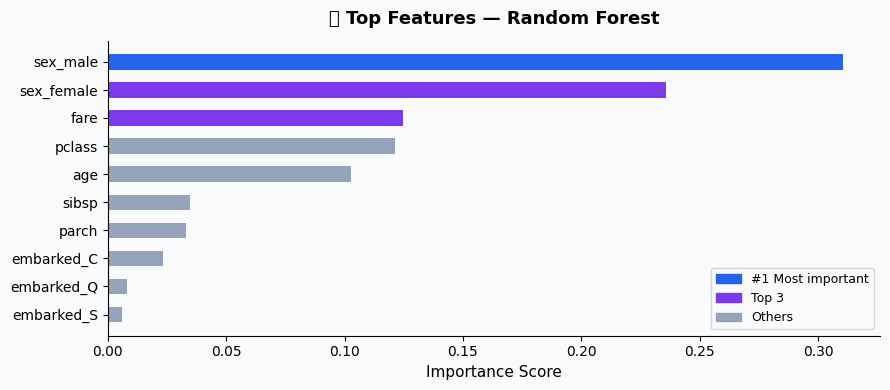

📸 Saved: feature_importance.png


,feature,importance
0,sex_male,0.310650
1,sex_female,0.235648
2,fare,0.124748
3,pclass,0.121480
4,age,0.102699
5,sibsp,0.034876
6,parch,0.032980
7,embarked_C,0.023088
8,embarked_Q,0.007991
9,embarked_S,0.005840


In [7]:
def get_feature_names(pre, num_cols, cat_cols):
    names = list(num_cols)
    try:
        enc = pre.named_transformers_['cat'].named_steps['enc']
        names += list(enc.get_feature_names_out(cat_cols))
    except Exception:
        names += cat_cols
    return names

estimator  = best['pipe'].named_steps['clf']
pre        = best['pipe'].named_steps['pre']
feat_names = get_feature_names(pre, num_cols, cat_cols)

if hasattr(estimator, 'feature_importances_'):
    imp = estimator.feature_importances_
elif hasattr(estimator, 'coef_'):
    c   = estimator.coef_
    imp = np.abs(c).mean(axis=0) if c.ndim > 1 else np.abs(c)
else:
    imp = None

if imp is not None:
    n  = min(len(feat_names), len(imp))
    fi = (pd.DataFrame({'feature': feat_names[:n], 'importance': imp[:n]})
            .sort_values('importance', ascending=False).head(10))

    fig, ax = plt.subplots(figsize=(9, 4))
    bar_colors = [COLORS['best'] if i == 0 else '#7C3AED' if i < 3 else COLORS['others']
                  for i in range(len(fi))]
    ax.barh(fi['feature'][::-1], fi['importance'][::-1],
            color=bar_colors[::-1], height=0.55, edgecolor='none')
    ax.set_xlabel('Importance Score', fontsize=11)
    ax.set_title(f'🔍 Top Features — {best["name"]}', fontsize=13, fontweight='bold', pad=12)
    legend_els = [mpatches.Patch(color=COLORS['best'], label='#1 Most important'),
                  mpatches.Patch(color='#7C3AED',      label='Top 3'),
                  mpatches.Patch(color=COLORS['others'],label='Others')]
    ax.legend(handles=legend_els, fontsize=9, loc='lower right')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('📸 Saved: feature_importance.png')
    display(fi.reset_index(drop=True))
else:
    print('ℹ️  Feature importance not available for this model.')

In [8]:
# Save
joblib.dump(best['pipe'], 'best_model.pkl')
if le:
    joblib.dump(le, 'label_encoder.pkl')
print('✅ Model saved → best_model.pkl\n')

# Sample predictions
sample  = X_test.head(5)
preds   = best['pipe'].predict(sample)
out_df  = sample.copy()
out_df['prediction'] = le.inverse_transform(preds) if le else preds

if PROBLEM == 'classification' and hasattr(best['pipe'], 'predict_proba'):
    proba = best['pipe'].predict_proba(sample).max(axis=1)
    out_df['confidence'] = [f'{p*100:.1f}%' for p in proba]

print('🔮 Sample Predictions:')
display(out_df)

# Final report
metric_label = 'Accuracy' if PROBLEM == 'classification' else 'R² Score'
print('\n' + '='*50)
print('       🤖 AutoML SYSTEM — FINAL REPORT')
print('='*50)
print(f'  Dataset   : {len(df)} rows × {X.shape[1]} features')
print(f'  Target    : {TARGET}')
print(f'  Problem   : {PROBLEM.upper()}')
print(f'  Best Model: {best["name"]}')
print(f'  {metric_label:<10}: {best["score"]:.4f}')
for k, v in best['extra'].items():
    print(f'  {k:<10}: {v:.4f}')
print()
print('  All Models:')
for i, r in enumerate(results):
    marker = '🏆' if i == 0 else '  '
    print(f'  {marker} {r["name"]:<25} {metric_label} = {r["score"]:.4f}')
print('='*50)

✅ Model saved → best_model.pkl

🔮 Sample Predictions:


,pclass,sex,age,sibsp,parch,fare,embarked,prediction,confidence
1306,3,male,26.5,0,0,7.2250,C,0,82.4%
974,3,male,30.0,1,0,16.1000,S,0,87.1%
937,3,female,1.0,1,1,12.1833,S,1,66.1%
29,1,male,28.0,0,0,26.5500,S,0,72.7%
474,2,male,31.0,0,0,10.5000,S,0,85.9%



       🤖 AutoML SYSTEM — FINAL REPORT
  Dataset   : 1043 rows × 7 features
  Target    : survived
  Problem   : CLASSIFICATION
  Best Model: Random Forest
  Accuracy  : 0.8230
  F1        : 0.8181

  All Models:
  🏆 Random Forest             Accuracy = 0.8230
     Gradient Boosting         Accuracy = 0.8134
     SVM                       Accuracy = 0.7943
     Logistic Regression       Accuracy = 0.7703


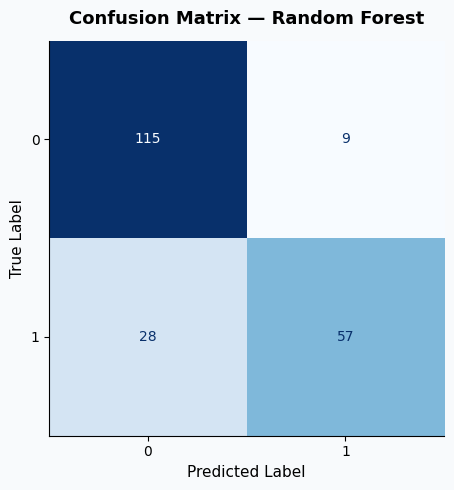

✅ Correctly predicted SURVIVED : 57
✅ Correctly predicted NOT survived : 115
❌ Wrong — predicted survived but didnt : 9
❌ Wrong — predicted not survived but did : 28


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_best = best['pipe'].predict(X_test)

cm  = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=le.classes_ if le else None)
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title(f'Confusion Matrix — {best["name"]}', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Breakdown
tn, fp, fn, tp = cm.ravel()
print(f'✅ Correctly predicted SURVIVED : {tp}')
print(f'✅ Correctly predicted NOT survived : {tn}')
print(f'❌ Wrong — predicted survived but didnt : {fp}')
print(f'❌ Wrong — predicted not survived but did : {fn}')

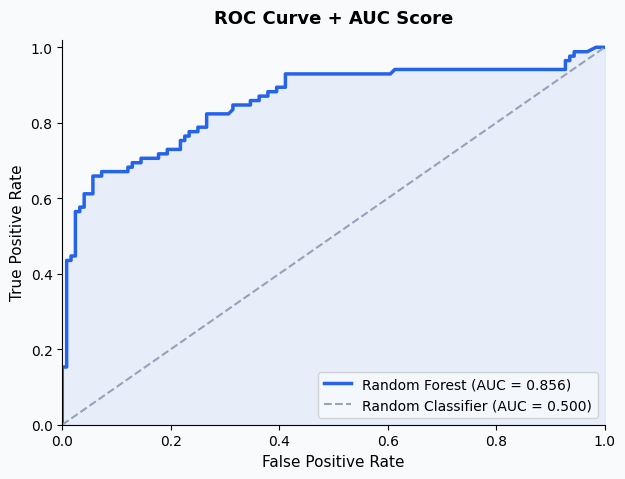

In [10]:
from sklearn.metrics import roc_curve, auc

y_proba = best['pipe'].predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(fpr, tpr, color=COLORS['best'], lw=2.5,
        label=f'{best["name"]} (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color=COLORS['others'], lw=1.5,
        linestyle='--', label='Random Classifier (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.08, color=COLORS['best'])

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve + AUC Score', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# AUC rating
if roc_auc >= 0.9:
    r

🔄 Running 5-Fold Cross Validation...

  Random Forest             Mean=0.6979  Std=0.1352
  Gradient Boosting         Mean=0.7046  Std=0.1330
  SVM                       Mean=0.7085  Std=0.1339
  Logistic Regression       Mean=0.7257  Std=0.1226


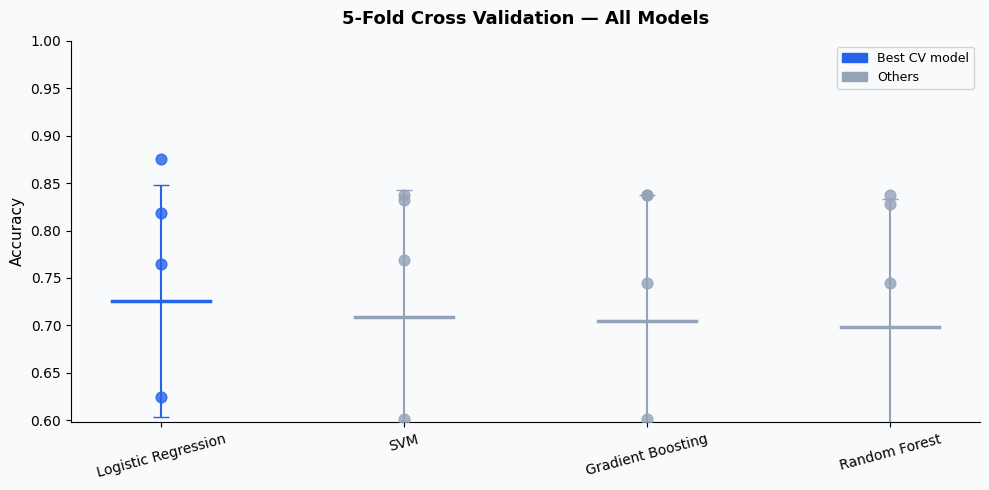


🏆 Best CV Model : Logistic Regression
   Mean Accuracy : 0.7257 ± 0.1226


In [11]:
from sklearn.model_selection import cross_val_score

print('🔄 Running 5-Fold Cross Validation...\n')

cv_results = []

for r in results:
    cv_scores = cross_val_score(r['pipe'], X, y, cv=5,
                                scoring='accuracy', n_jobs=-1)
    cv_results.append({
        'name'   : r['name'],
        'mean'   : cv_scores.mean(),
        'std'    : cv_scores.std(),
        'scores' : cv_scores
    })
    print(f'  {r["name"]:<25} Mean={cv_scores.mean():.4f}  Std={cv_scores.std():.4f}')

cv_results.sort(key=lambda x: x['mean'], reverse=True)
best_cv = cv_results[0]

# ── Plot ──
fig, ax = plt.subplots(figsize=(10, 5))

for i, r in enumerate(cv_results):
    color = COLORS['best'] if r['name'] == best_cv['name'] else COLORS['others']
    ax.scatter([r['name']] * 5, r['scores'],
               color=color, s=60, zorder=3, alpha=0.8)
    ax.plot([i - 0.2, i + 0.2], [r['mean'], r['mean']],
            color=color, lw=2.5, zorder=4)
    ax.errorbar(i, r['mean'], yerr=r['std'],
                fmt='none', color=color, capsize=6, lw=1.5)

ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('5-Fold Cross Validation — All Models', fontsize=13,
             fontweight='bold', pad=12)
ax.tick_params(axis='x', rotation=15)
ax.set_ylim(min([r['mean'] for r in cv_results]) - 0.1, 1.0)

legend_els = [mpatches.Patch(color=COLORS['best'],   label='Best CV model'),
              mpatches.Patch(color=COLORS['others'],  label='Others')]
ax.legend(handles=legend_els, fontsize=9)

plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🏆 Best CV Model : {best_cv["name"]}')
print(f'   Mean Accuracy : {best_cv["mean"]:.4f} ± {best_cv["std"]:.4f}')